In [ ]:
# ============================================================
# Dataset: Bank of England Base Rate
# Purpose: Clean and convert daily interest rate data to quarterly averages (Q3 2016 — Q4 2025)
# ============================================================

import pandas as pd

# Load raw Bank of England base rate CSV
# Data downloaded from datahub.io containing daily rate change records
df = pd.read_csv('/content/drive/MyDrive/DDA/datasets/bank_rate_data.csv')

# Rename columns to standard names
df.columns = ['date', 'rate']

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically
df = df.sort_values('date').reset_index(drop=True)

# Start from 2015 so forward fill correctly populates early 2016 when rates only change on updates
df_extended = df[df['date'] >= '2015-01-01']

# Create complete daily date range
daily_dates = pd.date_range(start='2015-01-01', end='2025-12-31', freq='D')
daily_df    = pd.DataFrame({'date': daily_dates})

# Forward fill interest rate to every day
daily_df = pd.merge_asof(daily_df, df_extended, on='date')
daily_df['rate'] = daily_df['rate'].ffill()

# Filter to study period (2016 onwards)
daily_df = daily_df[daily_df['date'] >= '2016-01-01']

# Convert to quarterly periods
daily_df['Quarter'] = daily_df['date'].dt.to_period('Q')

# Calculate average interest rate per quarter
result = daily_df.groupby('Quarter')['rate'].mean().reset_index()
result['Average_Interest_Rate'] = result['rate'].round(4)
result = (result
          .drop(columns=['rate'])
          .sort_values('Quarter')
          .reset_index(drop=True))

# Convert quarter format to agreed team standard
result['Quarter'] = result['Quarter'].astype(str)
result['Quarter'] = result['Quarter'].apply(
    lambda x: f"Q{x[-1]} {x[:4]}"
)

# Preview and validate
print("Cleaned Interest Rate Data:")
print(result)
print(f"\nTotal quarters: {len(result)}")
print(f"Date range: {result['Quarter'].iloc[0]} to "
      f"{result['Quarter'].iloc[-1]}")
print(f"Rate range: {result['Average_Interest_Rate'].min()}% "
      f"to {result['Average_Interest_Rate'].max()}%")
print(f"Missing values: {result.isnull().sum().sum()}")

# Save
# Format: Quarter, Average_Interest_Rate
result.to_csv(
    '/content/drive/MyDrive/DDA/datasets/cleaned_interest_rate.csv',
    index=False
)

Cleaned Interest Rate Data:
    Quarter  Average_Interest_Rate
0   Q1 2016                 0.5000
1   Q2 2016                 0.5000
2   Q3 2016                 0.3424
3   Q4 2016                 0.2500
4   Q1 2017                 0.2500
5   Q2 2017                 0.2500
6   Q3 2017                 0.2500
7   Q4 2017                 0.4130
8   Q1 2018                 0.5000
9   Q2 2018                 0.5000
10  Q3 2018                 0.6630
11  Q4 2018                 0.7500
12  Q1 2019                 0.7500
13  Q2 2019                 0.7500
14  Q3 2019                 0.7500
15  Q4 2019                 0.7500
16  Q1 2020                 0.6132
17  Q2 2020                 0.1000
18  Q3 2020                 0.1000
19  Q4 2020                 0.1000
20  Q1 2021                 0.1000
21  Q2 2021                 0.1000
22  Q3 2021                 0.1000
23  Q4 2021                 0.1261
24  Q1 2022                 0.4500
25  Q2 2022                 0.9478
26  Q3 2022                

In [ ]:
# ============================================================
# Step 1: Loading, Exploring and Cleaning the Merged Dataset
# Purpose: Load the team-merged dataset, validate quality, remove out-of-scope rows and confirm readiness
#          for EDA and machine learning modelling.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged dataset
df = pd.read_csv(
    '/content/drive/MyDrive/DDA/datasets/merged_complete_dataset.csv'
)

# Initial overview
print("Dataset Overview")
print(f"Shape: {df.shape}")
print(f"\n── Column data types: ────────────────────────────────────")
print(df.dtypes)
print(f"\n── First 5 rows: ────────────────────────────────────")
print(df.head())

# Check for missing values
print("\n── Missing Values per Column ────────────────────────────────────")
print(df.isnull().sum())

# Check categorical column values
print("\n── Unique Values in Categorical Columns ────────────────────────────────────")
print("Quarters:", df['Quarter'].unique())
print("\nSectors:", df['Sector'].unique())
print("\nLocations:", df['Location'].unique())

# Validate data quality
# 1. Q1 2026 rows — beyond interest rate data coverage
# 2. Unknown sector rows — missing sector classification
# 3. Location distribution — check for imbalance
print("\n── Data Quality Checks ────────────────────────────────────")
print(f"Q1 2026 rows (to remove):    {(df['Quarter'] == 'Q1 2026').sum()}")
print(f"Unknown sector rows (keep):  {(df['Sector'] == 'Unknown').sum()}")
print(f"\n── Location distribution: ────────────────────────────────────")
print(df['Location'].value_counts())

# Remove Q1 2026 rows
# Q1 2026 rows are removed because the Bank of England interest rate
# dataset only covers up to Q4 2025.
# Unknown sector rows are RETAINED as they contain valid insolvency
# counts and removal would introduce selection bias.
df = df[df['Quarter'] != 'Q1 2026'].reset_index(drop=True)

# Validate removal
print("\n── Post-Cleaning Validation ─────────────────────────────────")
print(f"Shape after removing Q1 2026: {df.shape}")
print(f"Q1 2026 rows remaining:       "
      f"{(df['Quarter'] == 'Q1 2026').sum()}")

# ── Final dataset summary ─────────────────────────────────────────────
print("\n── Final Dataset Summary ────────────────────────────────────")
print(f"Dataset shape:  {df.shape}")
print(f"Date range:     {df['Quarter'].iloc[0]} "
      f"to {df['Quarter'].iloc[-1]}")
print(f"Missing values: {df.isnull().sum().sum()} "
      f"(across all columns)")
print(f"\nKey Statistics:")
print(df[['Insolvency_Count',
          'Average_Interest_Rate',
          'Energy_Price_Index',
          'Regional_GDP']].describe().round(2))

Dataset Overview
Shape: (1506, 16)

── Column data types: ────────────────────────────────────
year_int                   int64
quarter_num                int64
Quarter                   object
Sector                    object
Location                  object
Insolvency_Count           int64
time_index               float64
lag_1                    float64
lag_2                    float64
rolling_avg_4            float64
Sector_code                int64
Location_code              int64
Risk_level                 int64
Average_Interest_Rate    float64
Energy_Price_Index       float64
Regional_GDP             float64
dtype: object

── First 5 rows: ────────────────────────────────────
   year_int  quarter_num  Quarter                Sector       Location  \
0      2016            3  Q3 2016  Accommodation & Food  England/Wales   
1      2016            4  Q4 2016  Accommodation & Food  England/Wales   
2      2017            1  Q1 2017  Accommodation & Food  England/Wales   
3      2017 

Dataset from Step 1: (1468, 16)
Q1 2026 rows remaining: 0
Date range: Q3 2016 to Q4 2025
Total quarters: 38


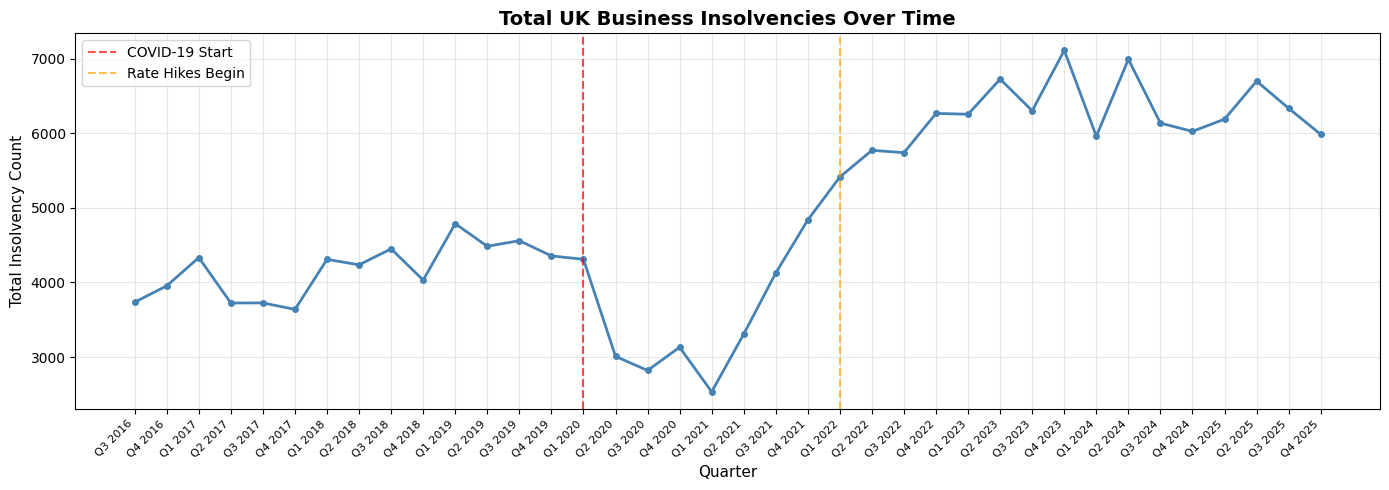

Chart 1 saved: eda_chart1_trend.png


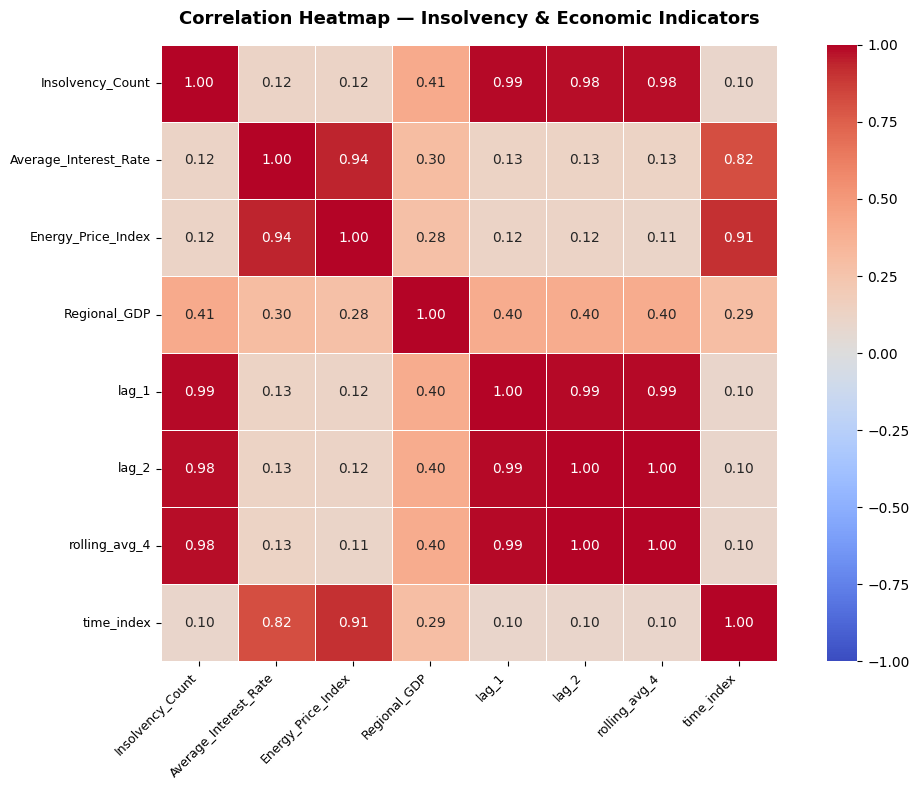

Chart 2 saved: eda_chart2_correlation.png

Correlation with Insolvency_Count:
Insolvency_Count         1.00
lag_1                    0.99
lag_2                    0.98
rolling_avg_4            0.98
Regional_GDP             0.41
Average_Interest_Rate    0.12
Energy_Price_Index       0.12
time_index               0.10
Name: Insolvency_Count, dtype: float64


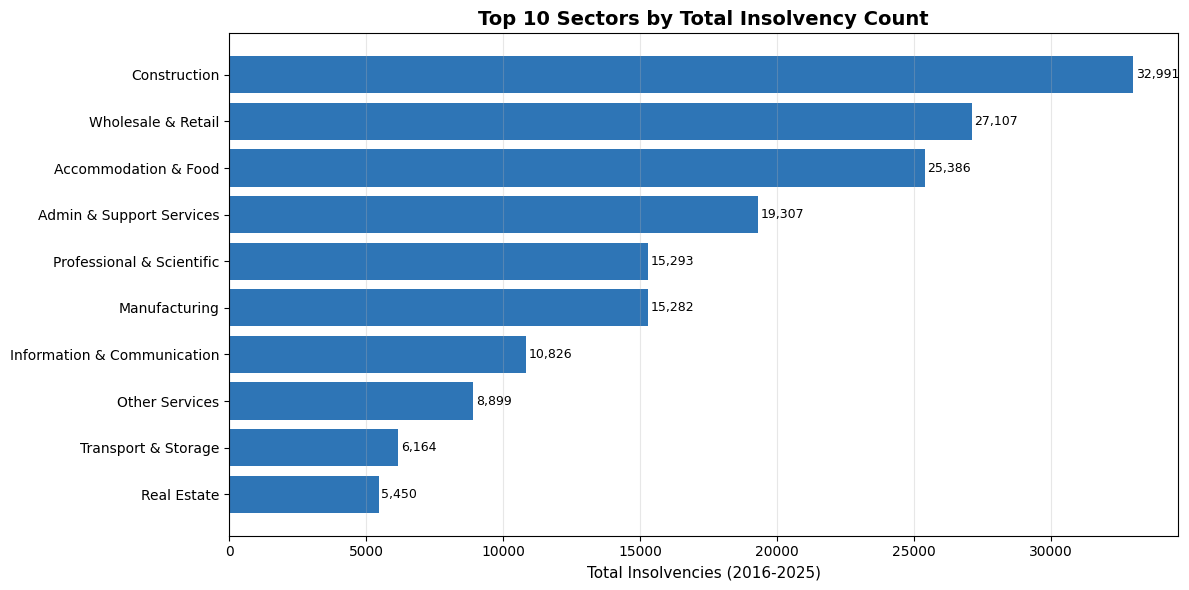

Chart 3 saved: eda_chart3_sectors.png


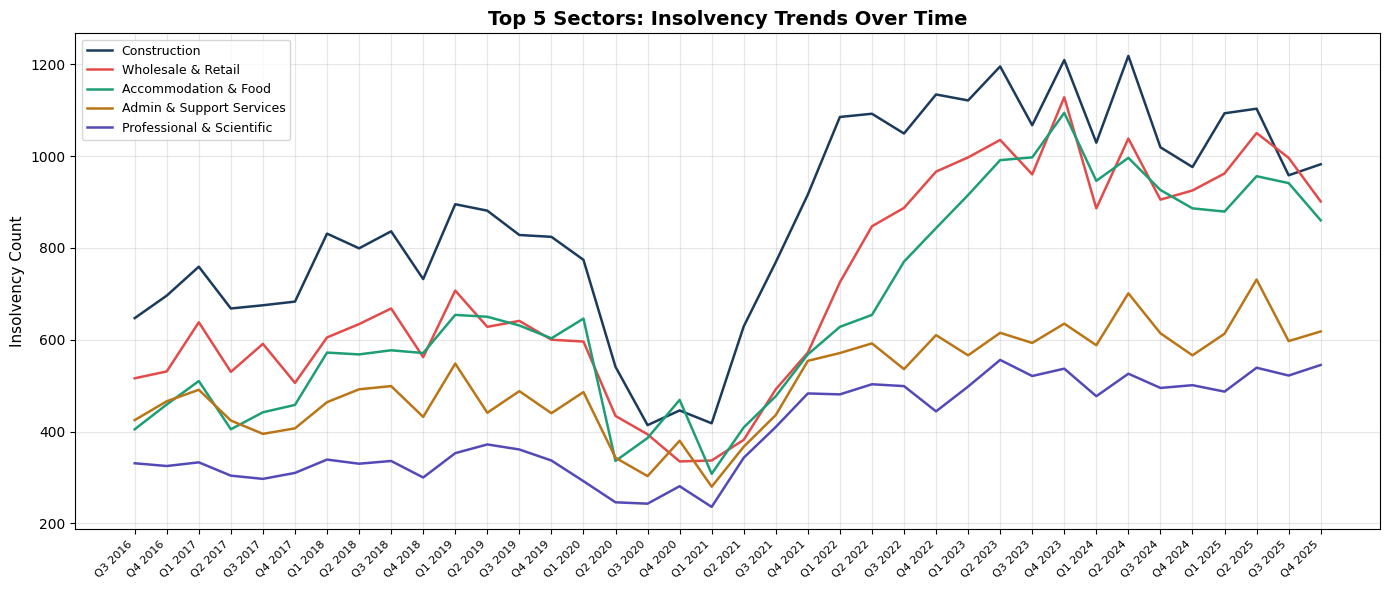

Chart 4 saved: eda_chart4_sectors_time.png


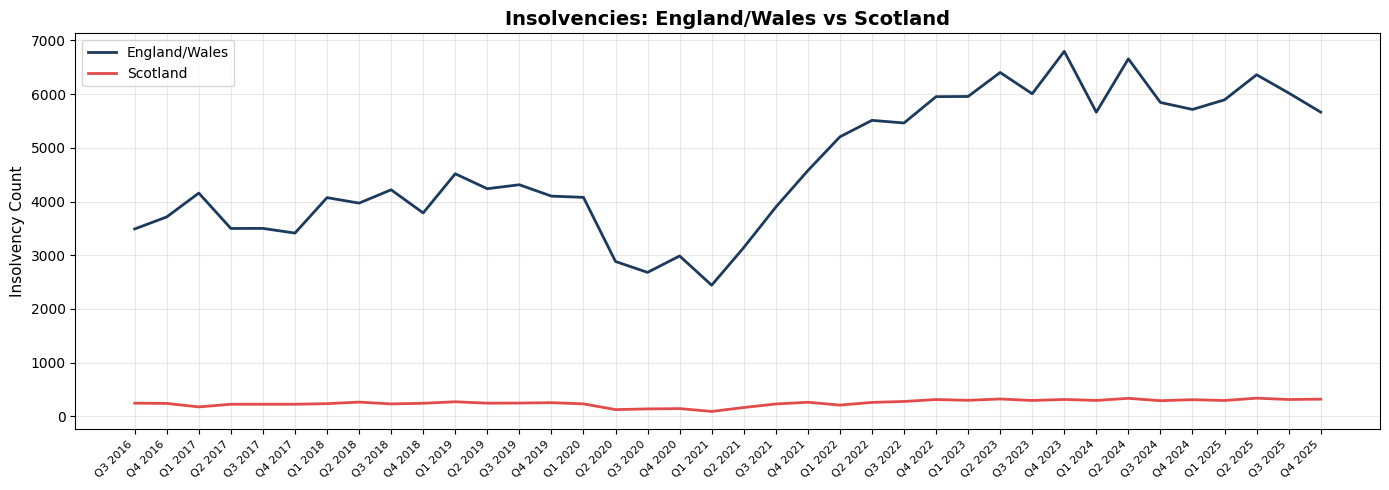

Chart 5 saved: eda_chart5_location.png


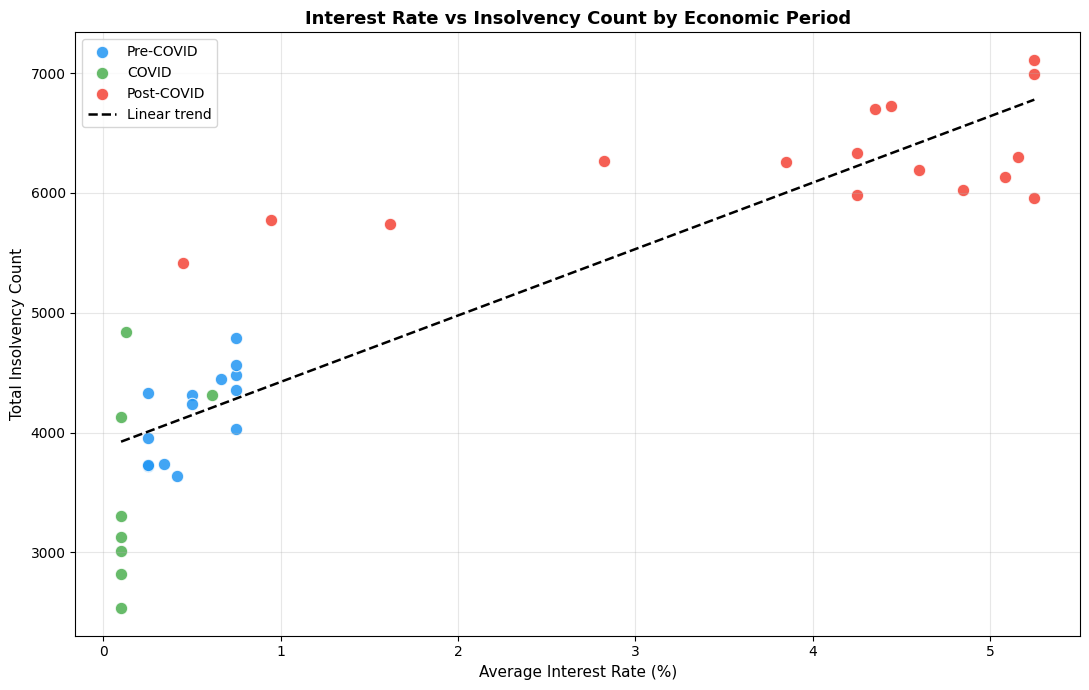

Chart 6 saved: eda_chart6_scatter.png


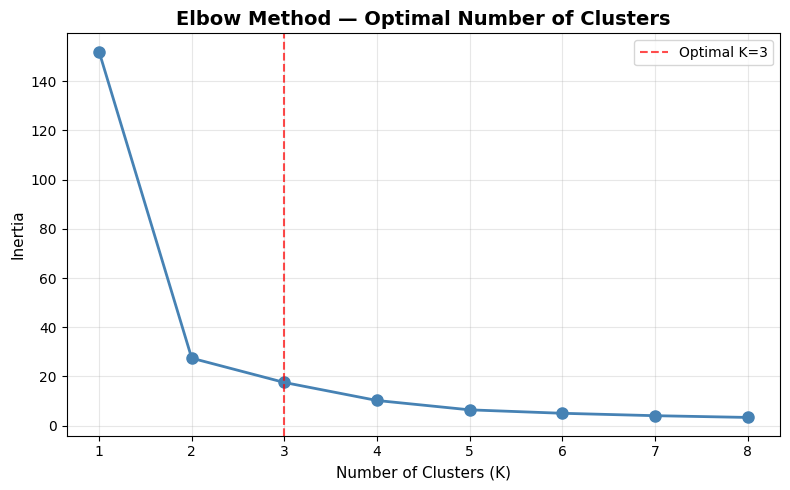

Chart 7 saved: eda_chart7_elbow.png


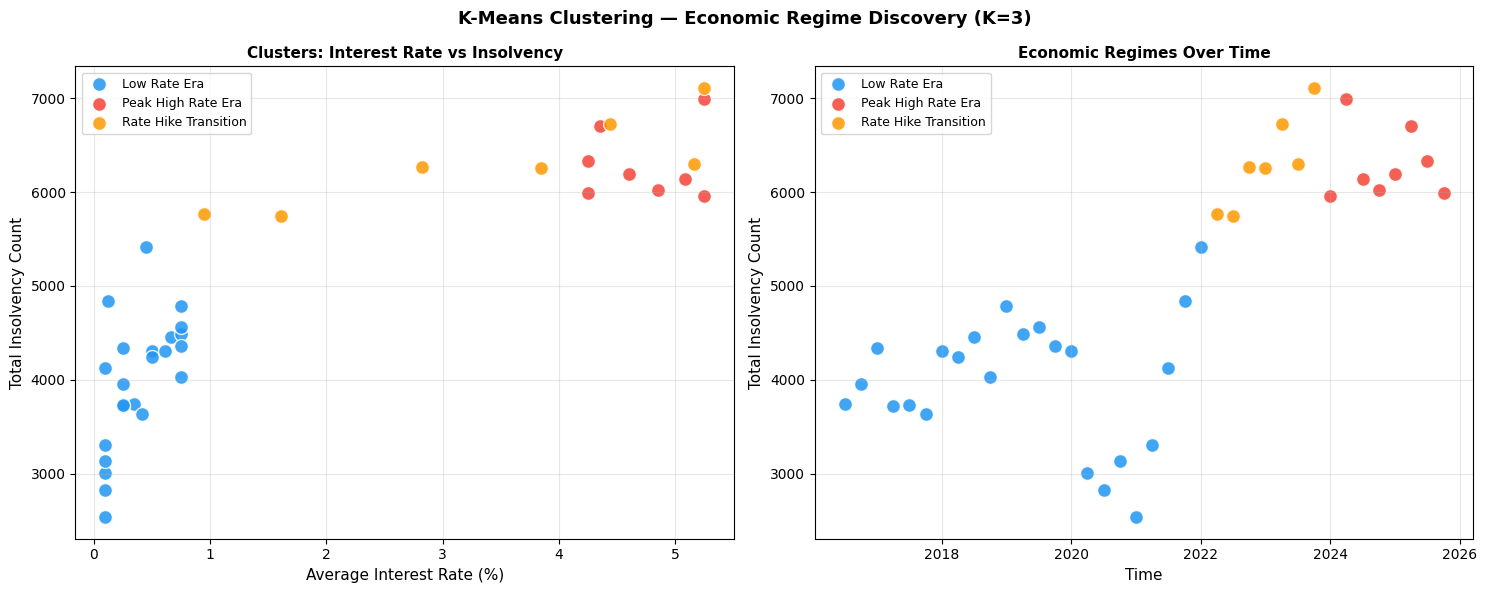

Chart 8 saved: eda_chart8_kmeans.png

Cluster Summary:
                      Avg_Insolvency  Avg_Rate  Quarter_Count
Cluster_Name                                                 
Low Rate Era                 3992.70      0.39             23
Peak High Rate Era           6291.12      4.74              8
Rate Hike Transition         6311.14      3.44              7


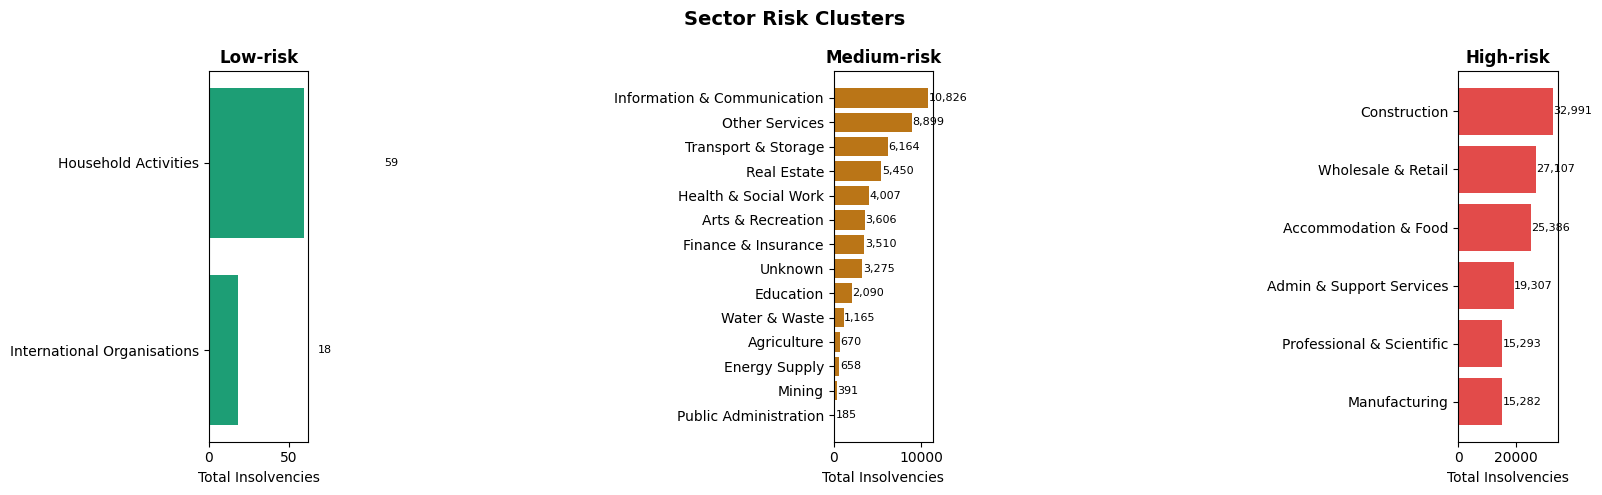

Chart 9 saved: eda_chart9_sector_clusters.png


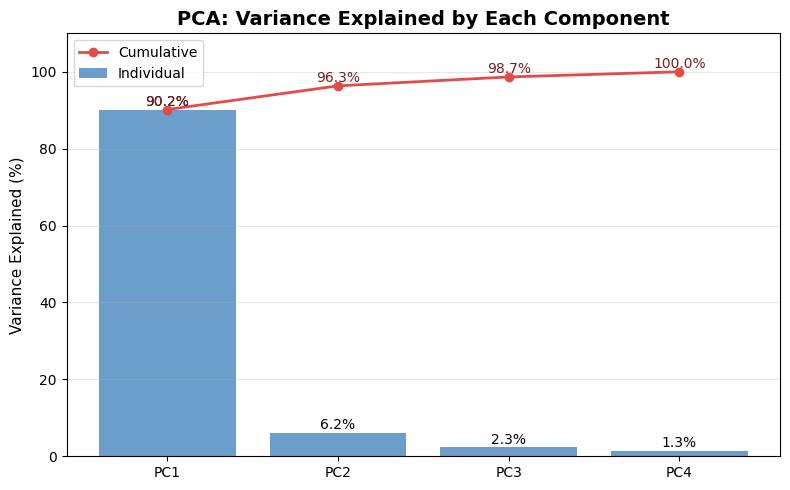

Chart 10 saved: eda_chart10_pca_variance.png


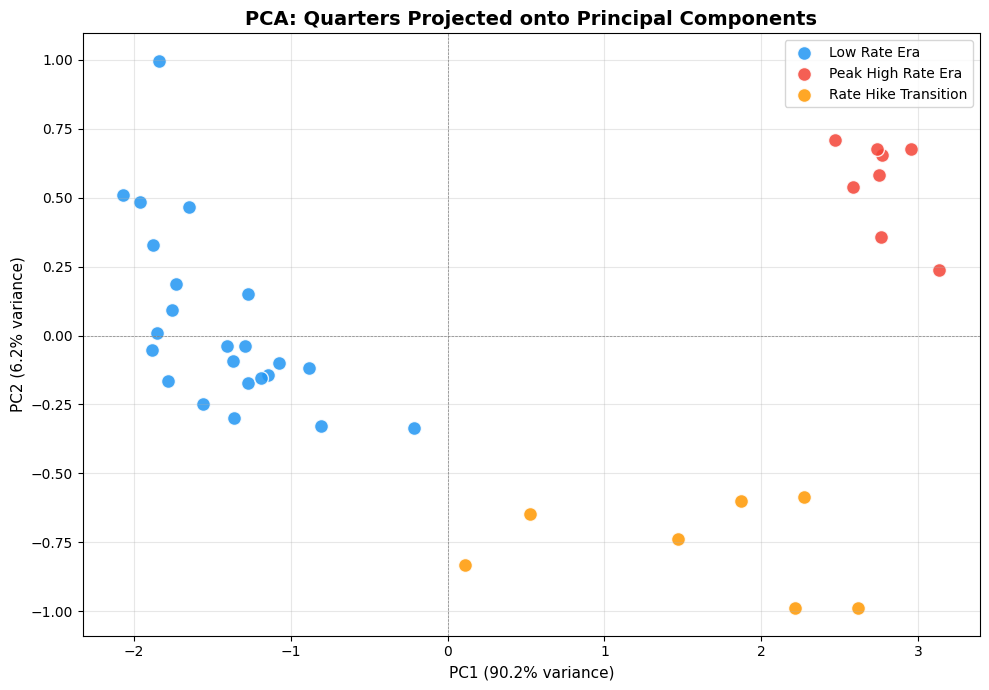

Chart 11 saved: eda_chart11_pca_scatter.png


In [ ]:
# ============================================================
# Step 2: Exploratory Data Analysis (Group Contribution)
# Purpose: Comprehensive EDA of UK business insolvency data using 11 visualisations including K-Means clustering and PCA.
# Charts: 11 total covering temporal trends, correlations, sectoral analysis, location comparison, clustering
#         and dimensionality reduction.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Use cleaned dataset from Step 1 ──────────────────────────────────
print(f"Dataset from Step 1: {df.shape}")
print(f"Q1 2026 rows remaining: {(df['Quarter'] == 'Q1 2026').sum()}")

# ── Sort chronologically ──────────────────────────────────────────────
# Sort by time_index to ensure all charts display correctly
df = df.sort_values('time_index').reset_index(drop=True)
quarter_order = (df.drop_duplicates('Quarter')
                   .sort_values('time_index')['Quarter']
                   .tolist())

print(f"Date range: {quarter_order[0]} to {quarter_order[-1]}")
print(f"Total quarters: {len(quarter_order)}")

# ─────────────────────────────────────────────────────────────────────
# CHART 1: Total Insolvencies Over Time
# Shows the full temporal story of UK business insolvencies —
# pre-COVID stability, COVID suppression and post-rate-hike surge.
# Reference lines mark COVID-19 start and Bank of England rate hikes.
# ─────────────────────────────────────────────────────────────────────
quarterly_total = (df.groupby('Quarter')['Insolvency_Count']
                     .sum().reset_index())
quarterly_total['Quarter'] = pd.Categorical(quarterly_total['Quarter'], categories=quarter_order, ordered=True)
quarterly_total = quarterly_total.sort_values('Quarter')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(quarterly_total['Quarter'],
        quarterly_total['Insolvency_Count'],
        color='steelblue', linewidth=2,
        marker='o', markersize=4)
ax.axvline(x='Q1 2020', color='red', linestyle='--',
           alpha=0.7, label='COVID-19 Start')
ax.axvline(x='Q1 2022', color='orange', linestyle='--',
           alpha=0.7, label='Rate Hikes Begin')
ax.set_title('Total UK Business Insolvencies Over Time',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Total Insolvency Count', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart1_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved: eda_chart1_trend.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 2: Correlation Heatmap
# Pearson correlation between all numeric features.
# Reveals which variables are most strongly associated with
# Insolvency_Count — directly informs ML feature selection.
# ─────────────────────────────────────────────────────────────────────
numeric_cols = [
    'Insolvency_Count', 'Average_Interest_Rate',
    'Energy_Price_Index', 'Regional_GDP',
    'lag_1', 'lag_2', 'rolling_avg_4', 'time_index'
]
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm',
    fmt='.2f', linewidths=0.5,
    vmin=-1, vmax=1, square=True, ax=ax
)

ax.set_title(
    'Correlation Heatmap — Insolvency & Economic Indicators',
    fontsize=13, fontweight='bold', pad=15
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved: eda_chart2_correlation.png")

# Print correlation with target for report
print("\nCorrelation with Insolvency_Count:")
print(corr_matrix['Insolvency_Count'].sort_values(ascending=False))

# ─────────────────────────────────────────────────────────────────────
# CHART 3: Top 10 Sectors by Total Insolvency Count
# Horizontal bar chart showing which sectors have highest total
# insolvencies across the full study period.
# Identifies most vulnerable sectors for discussion section.
# ─────────────────────────────────────────────────────────────────────
sector_total = (df.groupby('Sector')['Insolvency_Count']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(sector_total)), sector_total.values,
        color='#2E75B6')
ax.set_yticks(range(len(sector_total)))
ax.set_yticklabels(sector_total.index, fontsize=10)
ax.set_xlabel('Total Insolvencies (2016-2025)', fontsize=11)
ax.set_title('Top 10 Sectors by Total Insolvency Count',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(sector_total.values):
    ax.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart3_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved: eda_chart3_sectors.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 4: Top 5 Sectors Over Time
# Line chart showing quarterly insolvency trends for the 5 most
# affected sectors. Reveals whether sectors respond differently
# to the same macroeconomic shocks — important for model interpretation.
# ─────────────────────────────────────────────────────────────────────
top5 = (df.groupby('Sector')['Insolvency_Count']
          .sum()
          .sort_values(ascending=False)
          .head(5).index.tolist())
df_top5 = df[df['Sector'].isin(top5)]
sector_quarterly = (df_top5.groupby(['Quarter', 'Sector'])
                            ['Insolvency_Count'].sum().reset_index())
sector_quarterly['Quarter'] = pd.Categorical(
    sector_quarterly['Quarter'],
    categories=quarter_order, ordered=True
)
sector_quarterly = sector_quarterly.sort_values('Quarter')

fig, ax = plt.subplots(figsize=(14, 6))
colors_top5 = ['#1B3A5C', '#E24B4A', '#1D9E75', '#BA7517', '#534AB7']
for i, sector in enumerate(top5):
    data = sector_quarterly[sector_quarterly['Sector'] == sector]
    ax.plot(data['Quarter'], data['Insolvency_Count'],
            label=sector, linewidth=1.8, color=colors_top5[i])
ax.set_title('Top 5 Sectors: Insolvency Trends Over Time',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Insolvency Count', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart4_sectors_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved: eda_chart4_sectors_time.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 5: England/Wales vs Scotland Comparison
# Compares insolvency trends between the two locations over time.
# England/Wales has more businesses so higher absolute counts —
# important context for interpreting location-level predictions.
# ─────────────────────────────────────────────────────────────────────
loc_quarterly = (df.groupby(['Quarter', 'Location'])
                   ['Insolvency_Count'].sum().reset_index())
loc_quarterly['Quarter'] = pd.Categorical(
    loc_quarterly['Quarter'],
    categories=quarter_order, ordered=True
)
loc_quarterly = loc_quarterly.sort_values('Quarter')

fig, ax = plt.subplots(figsize=(14, 5))
for loc, color in [('England/Wales', '#1B3A5C'),
                   ('Scotland', '#E24B4A')]:
    data = loc_quarterly[loc_quarterly['Location'] == loc]
    ax.plot(data['Quarter'], data['Insolvency_Count'],
            label=loc, linewidth=2, color=color)
ax.set_title('Insolvencies: England/Wales vs Scotland',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Insolvency Count', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart5_location.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved: eda_chart5_location.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 6: Interest Rate vs Insolvency Scatter
# Scatter plot coloured by economic period testing research hypothesis:
# do higher interest rates associate with more insolvencies?
# Trend line shows overall direction of relationship.
# ─────────────────────────────────────────────────────────────────────
q_total = df.groupby('Quarter')['Insolvency_Count'].sum().reset_index()
q_rate  = df.groupby('Quarter')['Average_Interest_Rate'].mean().reset_index()
q_merged = q_total.merge(q_rate, on='Quarter')
q_time   = df.drop_duplicates('Quarter')[['Quarter', 'time_index']]
q_merged = (q_merged.merge(q_time, on='Quarter')
                    .sort_values('time_index'))

def assign_period(q):
    """Assign economic period label based on quarter string"""
    y = int(q[3:])
    if y < 2020:   return 'Pre-COVID'
    elif y <= 2021: return 'COVID'
    else:           return 'Post-COVID'

q_merged['Period'] = q_merged['Quarter'].apply(assign_period)
color_map = {
    'Pre-COVID':  '#2196F3',
    'COVID':      '#4CAF50',
    'Post-COVID': '#F44336'
}

fig, ax = plt.subplots(figsize=(11, 7))
for period, color in color_map.items():
    data = q_merged[q_merged['Period'] == period]
    ax.scatter(
        data['Average_Interest_Rate'],
        data['Insolvency_Count'],
        c=color, s=80, alpha=0.85,
        edgecolors='white', linewidth=0.8,
        label=period
    )

# Linear trend line
z      = np.polyfit(q_merged['Average_Interest_Rate'],
                    q_merged['Insolvency_Count'], 1)
p      = np.poly1d(z)
x_line = np.linspace(
    q_merged['Average_Interest_Rate'].min(),
    q_merged['Average_Interest_Rate'].max(), 100
)
ax.plot(x_line, p(x_line),
        color='black', linestyle='--', linewidth=1.8,
        label='Linear trend')

ax.set_xlabel('Average Interest Rate (%)', fontsize=11)
ax.set_ylabel('Total Insolvency Count', fontsize=11)
ax.set_title(
    'Interest Rate vs Insolvency Count by Economic Period',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved: eda_chart6_scatter.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 7: K-Means Elbow Method
# Determines optimal number of clusters K using inertia.
# Inertia = within-cluster sum of squared distances to centroid.
# Elbow at K=3 confirms three economic regimes in the data.
# ─────────────────────────────────────────────────────────────────────
q_cluster = (df.groupby('Quarter').agg({
    'Insolvency_Count':      'sum',
    'Average_Interest_Rate': 'mean',
    'Energy_Price_Index':    'mean',
    'Regional_GDP':          'mean',
    'time_index':            'first'
}).reset_index().sort_values('time_index'))

features_cluster = [
    'Insolvency_Count', 'Average_Interest_Rate',
    'Energy_Price_Index', 'Regional_GDP'
]

# StandardScaler converts all features to mean=0, std=1
# Prevents GDP (millions) dominating distance calculations
scaler    = StandardScaler()
X_cluster = scaler.fit_transform(q_cluster[features_cluster])

inertias = []
k_range  = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, 'o-',
        color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=3, color='red', linestyle='--',
           alpha=0.7, label='Optimal K=3')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Elbow Method — Optimal Number of Clusters',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart7_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved: eda_chart7_elbow.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 8: K-Means Clustering Results
# Applies K-Means with K=3 to discover economic regimes.
# Clusters named by average interest rate rank.
# Two panels: interest rate vs insolvency and clusters over time.
# ─────────────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
q_cluster['Cluster'] = km_final.fit_predict(X_cluster)

# Name clusters by interest rate rank — programmatic not manual
cluster_avg_rate = (q_cluster.groupby('Cluster')
                              ['Average_Interest_Rate']
                              .mean().rank().to_dict())
name_map = {
    c: ('Low Rate Era'
        if r == 1 else
        'Rate Hike Transition'
        if r == 2 else
        'Peak High Rate Era')
    for c, r in cluster_avg_rate.items()
}
q_cluster['Cluster_Name'] = q_cluster['Cluster'].map(name_map)

cluster_colors = {
    'Low Rate Era':         '#2196F3',
    'Rate Hike Transition': '#FF9800',
    'Peak High Rate Era':   '#F44336'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: Interest Rate vs Insolvency by cluster
for name, group in q_cluster.groupby('Cluster_Name'):
    axes[0].scatter(
        group['Average_Interest_Rate'],
        group['Insolvency_Count'],
        c=cluster_colors[name], s=100,
        alpha=0.85, edgecolors='white',
        label=name
    )
axes[0].set_xlabel('Average Interest Rate (%)', fontsize=11)
axes[0].set_ylabel('Total Insolvency Count', fontsize=11)
axes[0].set_title('Clusters: Interest Rate vs Insolvency',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right panel: Clusters over time
for name, group in q_cluster.groupby('Cluster_Name'):
    axes[1].scatter(
        group['time_index'],
        group['Insolvency_Count'],
        c=cluster_colors[name], s=100,
        alpha=0.85, edgecolors='white',
        label=name
    )
axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_ylabel('Total Insolvency Count', fontsize=11)
axes[1].set_title('Economic Regimes Over Time',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(
    'K-Means Clustering — Economic Regime Discovery (K=3)',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart8_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved: eda_chart8_kmeans.png")

# Print cluster summary
print("\nCluster Summary:")
summary = q_cluster.groupby('Cluster_Name').agg({
    'Insolvency_Count':      'mean',
    'Average_Interest_Rate': 'mean',
    'Quarter':               'count'
}).round(2)
summary.columns = ['Avg_Insolvency', 'Avg_Rate', 'Quarter_Count']
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────
# CHART 9: Sector Risk Clustering
# Second K-Means application — clusters sectors by their economic
# risk profile (average insolvency rate, interest rate exposure,
# energy price exposure). Reveals which sectors are structurally
# high/medium/low risk regardless of time period.
# ─────────────────────────────────────────────────────────────────────
sector_stats = df.groupby('Sector').agg(
    total=('Insolvency_Count', 'sum'),
    avg_q=('Insolvency_Count', 'mean'),
    avg_rate=('Average_Interest_Rate', 'mean'),
    avg_energy=('Energy_Price_Index', 'mean')
).reset_index()

# Standardise sector features before clustering
X_sector   = StandardScaler().fit_transform(
    sector_stats[['avg_q', 'avg_rate', 'avg_energy']]
)
km_sector  = KMeans(n_clusters=3, random_state=42, n_init=10)
sector_stats['Cluster'] = km_sector.fit_predict(X_sector)

# Name clusters by average quarterly insolvency — lowest to highest
cluster_avg = sector_stats.groupby('Cluster')['avg_q'].mean()
sorted_c    = cluster_avg.sort_values().index.tolist()
risk_names  = {
    sorted_c[0]: 'Low-risk',
    sorted_c[1]: 'Medium-risk',
    sorted_c[2]: 'High-risk'
}
risk_colors = {
    sorted_c[0]: '#1D9E75',
    sorted_c[1]: '#BA7517',
    sorted_c[2]: '#E24B4A'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, c in enumerate(sorted_c):
    members = (sector_stats[sector_stats['Cluster'] == c]
               .sort_values('total', ascending=True))
    axes[i].barh(members['Sector'], members['total'],
                 color=risk_colors[c])
    axes[i].set_title(risk_names[c],
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Total Insolvencies')
    for _, row in members.iterrows():
        axes[i].text(
            row['total'] + 50, row['Sector'],
            f"{row['total']:,.0f}",
            va='center', fontsize=8
        )

plt.suptitle('Sector Risk Clusters',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart9_sector_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved: eda_chart9_sector_clusters.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 10: PCA Variance Explained
# Principal Component Analysis reduces 4 economic features to
# principal components ranked by variance explained.
# Shows how much of the data's variation each component captures —
# PC1 typically captures the dominant economic regime signal.
# ─────────────────────────────────────────────────────────────────────
pca_full      = PCA(n_components=4)
pca_full.fit(X_cluster)
var_explained = pca_full.explained_variance_ratio_ * 100
cumulative    = np.cumsum(var_explained)

fig, ax = plt.subplots(figsize=(8, 5))
components = ['PC1', 'PC2', 'PC3', 'PC4']
ax.bar(components, var_explained,
       color='#2E75B6', alpha=0.7, label='Individual')
ax.plot(components, cumulative, 'o-',
        color='#E24B4A', linewidth=2, label='Cumulative')
for i, (v, c) in enumerate(zip(var_explained, cumulative)):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)
    ax.text(i, c + 1, f'{c:.1f}%',
            ha='center', fontsize=10, color='#791F1F')
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax.set_title('PCA: Variance Explained by Each Component',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart10_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved: eda_chart10_pca_variance.png")

# ─────────────────────────────────────────────────────────────────────
# CHART 11: PCA Scatter Plot
# Projects quarterly data onto first two principal components.
# Colour coded by K-Means cluster to validate that economic regimes
# are linearly separable in reduced dimensional space —
# strengthening the K-Means clustering findings.
# ─────────────────────────────────────────────────────────────────────
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
q_cluster['PC1'] = X_pca[:, 0]
q_cluster['PC2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for name, group in q_cluster.groupby('Cluster_Name'):
    ax.scatter(
        group['PC1'], group['PC2'],
        c=cluster_colors[name], s=100,
        alpha=0.85, edgecolors='white',
        label=name
    )
ax.set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
    fontsize=11
)
ax.set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
    fontsize=11
)
ax.set_title(
    'PCA: Quarters Projected onto Principal Components',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DDA/charts/eda_chart11_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 11 saved: eda_chart11_pca_scatter.png")


In [ ]:
# ============================================================
# Step 3: Machine Learning — Imports
# Purpose: Import all required ML libraries for training and
#          evaluating three regression models to predict
#          UK business insolvency counts by region.
# ============================================================

# ─ Imports for Machine Learning ─────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import time

print("All ML libraries imported successfully!")

# ============================================================
# Step 3a: Define Features and Target Variable
# Purpose: Select predictor variables informed by EDA findings:
#          - eda_chart2_correlation.png: lag_1 r=0.99 strongest predictor — lag features prioritised as primary inputs
#          - eda_chart3_sectors.png: Construction, Wholesale & Retail highest insolvency — Sector_code included
#          - eda_chart5_location.png: England/Wales vs Scotland shows significant location difference — Location_code
#            included to capture geographic variation
#          - eda_chart9_sector_clusters.png: three distinct sector risk groups confirmed — Sector_code essential
#          Time-based split preserves temporal integrity of data and prevents data leakage in time series context.
# ============================================================

features = [
    'Average_Interest_Rate',  # Cost of borrowing
    'Energy_Price_Index',     # Cost of energy
    'Regional_GDP',           # Economic strength
    'lag_1',                  # Insolvency count previous quarter
    'lag_2',                  # Insolvency count 2 quarters ago
    'rolling_avg_4',          # Average insolvency over last 4 quarters
    'Sector_code',            # Sector encoded as number
    'Location_code',          # Location encoded as number
    'time_index'              # Sequential time marker
]

target = 'Insolvency_Count'

# ── Prepare clean dataset ─────────────────────────────────────────────
df_clean = df[features + [target]].dropna().reset_index(drop=True)
df_clean = df_clean.sort_values('time_index').reset_index(drop=True)
print(f"Clean dataset: {len(df_clean)} rows")
print(f"time_index range: {df_clean['time_index'].min()} "
      f"to {df_clean['time_index'].max()}")

X = df_clean[features]
y = df_clean[target]

# ── Robust time-based 80/20 train/test split ──────────────────────────
# Split by time_index VALUE not row position.
# time_index runs from 1 to 38 (38 quarters total)
# 80% cutoff = time_index <= 30 (approx Q4 2023)
cutoff_idx = df_clean['time_index'].quantile(0.8)
train_mask = df_clean['time_index'] <= cutoff_idx

X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Cutoff time_index: {cutoff_idx}")
print(f"Training rows: {len(X_train)} (80%)")
print(f"Testing rows:  {len(X_test)} (20%)")

# ============================================================
# Step 3b: Train Three Regression Models
# Purpose: Train models of increasing complexity to compare predictive performance. Model selection directly
#          motivated by EDA findings:
#          - eda_chart2_correlation.png: dominant linear autocorrelation signal → Linear Regression tested
#          - eda_chart8_kmeans.png: three distinct non-linear economic regimes → ensemble methods tested to
#            capture regime-specific patterns
#          - eda_chart6_scatter.png: positive but non-linear relationship between rate and insolvency across
#            periods → Gradient Boosting tested for non-linearity
# ============================================================

# ── Model 1: Linear Regression (Baseline) ────────────────────────────
# Finds the best straight line through the data
start         = time.time()
lr            = LinearRegression()
lr.fit(X_train, y_train)
lr_time       = time.time() - start
y_pred_lr     = lr.predict(X_test)

print(f"Linear Regression trained    ({lr_time:.3f} seconds)")

# ── Model 2: Random Forest ────────────────────────────────────────────
# Motivated by EDA Chart 8 (eda_chart8_kmeans.png) — K-Means
# identified three distinct economic regimes with different
# insolvency dynamics. Random Forest can capture regime-specific
# non-linear patterns that Linear Regression cannot.
# Also motivated by EDA Chart 9 (eda_chart9_sector_clusters.png)
# — three sector risk clusters suggest non-linear sectoral patterns.
start         = time.time()
rf            = RandomForestRegressor(
    n_estimators=200,    # Number of trees
    max_depth=10,        # Max depth of each tree — prevents overfitting
    random_state=42,     # Seed for reproducibility
    n_jobs=-1            # Use all available CPU cores
)
rf.fit(X_train, y_train)
rf_time       = time.time() - start
y_pred_rf     = rf.predict(X_test)

print(f"Random Forest trained        ({rf_time:.3f} seconds)")

# ── Model 3: Gradient Boosting ────────────────────────────────────────
# Motivated by EDA Chart 6 (eda_chart6_scatter.png) — scatter plot
# showed COVID period sits significantly below the linear trend,
# indicating structural break that requires sequential error
# correction to handle. Gradient Boosting corrects predecessor
# errors iteratively — well suited to regime transition points.
# Also motivated by EDA Chart 4 (eda_chart4_sectors_time.png)
# — top 5 sectors show different temporal patterns suggesting
# complex non-linear sector-time interactions
start         = time.time()
gb            = GradientBoostingRegressor(
    n_estimators=200,    # Number of trees
    max_depth=5,         # Shallower trees — they work together
    learning_rate=0.05,  # Small steps = careful learning = better accuracy
    random_state=42      # Seed for reproducibility
)
gb.fit(X_train, y_train)
gb_time       = time.time() - start
y_pred_gb     = gb.predict(X_test)

print(f"Gradient Boosting trained    ({gb_time:.3f} seconds)")

print("\nAll 3 models trained successfully!")
print(f"\nTraining times:")
print(f"  Linear Regression:  {lr_time:.3f} seconds")
print(f"  Random Forest:      {rf_time:.3f} seconds")
print(f"  Gradient Boosting:  {gb_time:.3f} seconds")

All ML libraries imported successfully!
Clean dataset: 1468 rows
time_index range: 2016.5 to 2025.75
Cutoff time_index: 2024.0
Training rows: 1190 (80%)
Testing rows:  278 (20%)
Linear Regression trained    (0.015 seconds)
Random Forest trained        (0.969 seconds)
Gradient Boosting trained    (0.752 seconds)

All 3 models trained successfully!

Training times:
  Linear Regression:  0.015 seconds
  Random Forest:      0.969 seconds
  Gradient Boosting:  0.752 seconds


In [ ]:
# ============================================================
# Step 3c: Evaluate All Three Models
# Purpose: Compare model performance using three complementary metrics.
# ============================================================

# ── Metric definitions ────────────────────────────────────────────────
# RMSE: average error in same units as insolvency count penalises large errors heavily — lower is better
# MAE:  average absolute error — treats all errors equally more intuitive interpretation — lower is better
# R²:   proportion of insolvency variation explained by model range 0 to 1 — higher is better
def evaluate_model(name, y_true, y_pred, train_time):
    """Calculate and print all evaluation metrics for a model"""

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE:          {rmse:.2f}")
    print(f"  MAE:           {mae:.2f}")
    print(f"  R²:            {r2:.4f}")
    print(f"  Training Time: {train_time:.3f} seconds")

    return {
        'Model':         name,
        'RMSE':          round(rmse, 2),
        'MAE':           round(mae, 2),
        'R2':            round(r2, 4),
        'Training_Time': round(train_time, 3)
    }

models = [
    ("Linear Regression (Baseline)", y_pred_lr, lr_time),
    ("Random Forest (sklearn)", y_pred_rf, rf_time),
    ("Gradient Boosting (sklearn)", y_pred_gb, gb_time),
]

results = []

for name, y_pred, runtime in models:
    metrics = evaluate_model(name, y_test, y_pred, runtime)
    results.append(metrics)

metrics_dict = {m['Model']: m for m in results}

lr_rmse = metrics_dict["Linear Regression (Baseline)"]['RMSE']
rf_rmse = metrics_dict["Random Forest (sklearn)"]['RMSE']
gb_rmse = metrics_dict["Gradient Boosting (sklearn)"]['RMSE']

lr_mae  = metrics_dict["Linear Regression (Baseline)"]['MAE']
rf_mae  = metrics_dict["Random Forest (sklearn)"]['MAE']
gb_mae  = metrics_dict["Gradient Boosting (sklearn)"]['MAE']

lr_r2   = metrics_dict["Linear Regression (Baseline)"]['R2']
rf_r2   = metrics_dict["Random Forest (sklearn)"]['R2']
gb_r2   = metrics_dict["Gradient Boosting (sklearn)"]['R2']

# ── Summary Table ─────────────────────────────────────────────────────
print(f"\n{'='*45}")
print("  SUMMARY TABLE")
print(f"{'='*45}")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ── Save ───────────────────────────────────────────────
results_df.to_csv(
    '/content/drive/MyDrive/DDA/results/vedanshi_ml_results.csv',
    index=False
)


  Linear Regression (Baseline)
  RMSE:          34.66
  MAE:           23.18
  R²:            0.9830
  Training Time: 0.015 seconds

  Random Forest (sklearn)
  RMSE:          34.69
  MAE:           17.71
  R²:            0.9830
  Training Time: 0.969 seconds

  Gradient Boosting (sklearn)
  RMSE:          38.46
  MAE:           18.79
  R²:            0.9791
  Training Time: 0.752 seconds

  SUMMARY TABLE
                       Model  RMSE   MAE     R2  Training_Time
Linear Regression (Baseline) 34.66 23.18 0.9830          0.015
     Random Forest (sklearn) 34.69 17.71 0.9830          0.969
 Gradient Boosting (sklearn) 38.46 18.79 0.9791          0.752


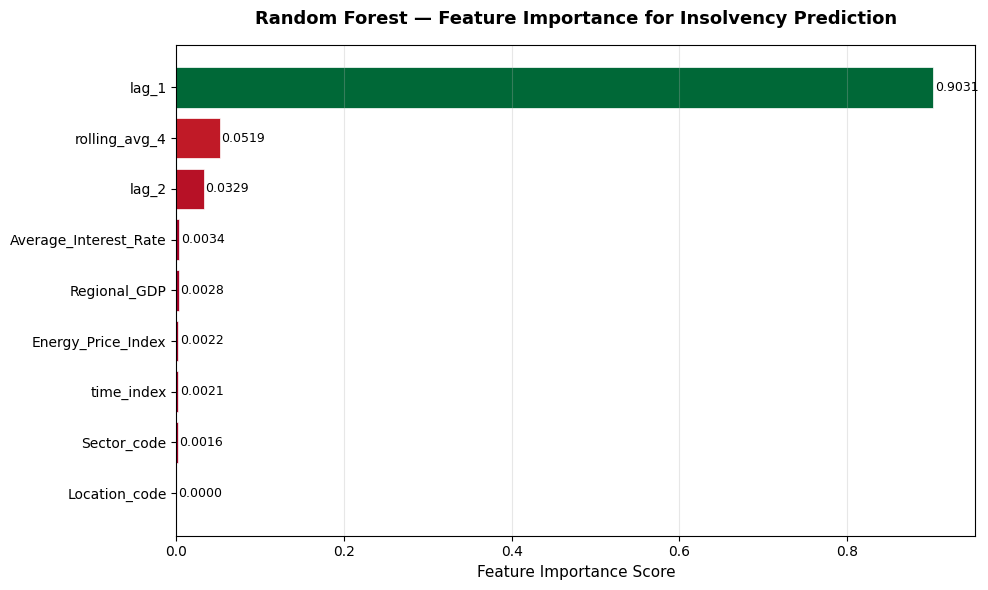

Feature Importance Rankings:
              Feature  Importance
                lag_1    0.903136
        rolling_avg_4    0.051879
                lag_2    0.032878
Average_Interest_Rate    0.003384
         Regional_GDP    0.002762
   Energy_Price_Index    0.002239
           time_index    0.002115
          Sector_code    0.001602
        Location_code    0.000005


In [ ]:
# ============================================================
# Step 3d: Feature Importance from Random Forest
# Purpose: Identify which factors most strongly drive insolvency predictions. Results validated against and compared
#          with EDA findings:
#          - eda_chart2_correlation.png: correlation rankings should align with importance rankings
#          - eda_chart3_sectors.png: high insolvency sectors should correspond to high Sector_code importance
#          - eda_chart9_sector_clusters.png: sector risk clusters should be reflected in Sector_code importance score
#          - eda_chart5_location.png: location difference should be reflected in Location_code importance score
#          Key finding — mediated causality: economic indicators show low direct importance but drive insolvency through
#          lag features as confirmed by EDA Chart 6 scatter plot.
# ============================================================

# ── Extract feature importances ───────────────────────────────────────
# Random Forest scores each feature by how much it reduces prediction
# error across all 200 trees — scores sum to 1.0
importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# ── Normalise for colormap ────────────────────────────────────────────
norm_vals = importance_df['Importance'].values / importance_df['Importance'].max()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=plt.cm.RdYlGn(norm_vals),
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on each bar
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Random Forest — Feature Importance for Insolvency Prediction',
             fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, importance_df['Importance'].max() + 0.05)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────
plt.savefig('/content/drive/MyDrive/DDA/charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print exact values
print("Feature Importance Rankings:")
print(importance_df.to_string(index=False))

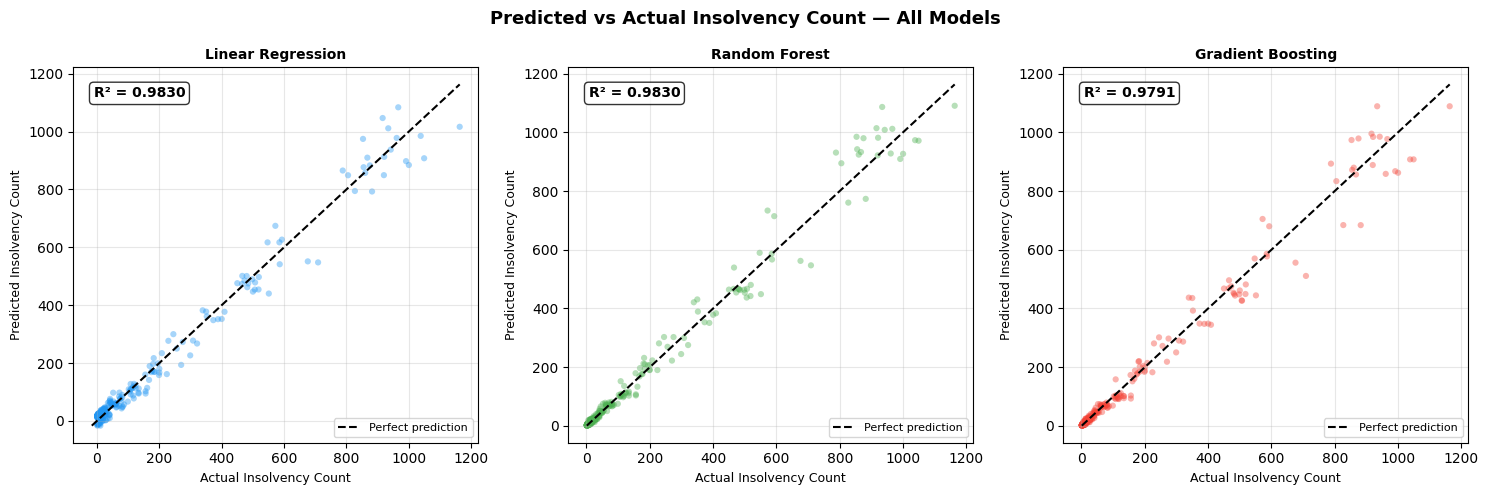

Predicted vs Actual chart saved!


In [ ]:
# ============================================================
# Step 3e: Predicted vs Actual Chart
# Purpose: Visually assess prediction accuracy for all three models. Points lying on the diagonal = perfect
#          prediction. Scatter around diagonal shows error magnitude and whether model under or over predicts.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Predicted vs Actual Insolvency Count — All Models',
             fontsize=13, fontweight='bold')

models_info = [
    ('Linear Regression', y_pred_lr, '#2196F3'),
    ('Random Forest',     y_pred_rf, '#4CAF50'),
    ('Gradient Boosting', y_pred_gb, '#F44336')
]

for ax, (name, y_pred, color) in zip(axes, models_info):

    # Scatter of predicted vs actual
    ax.scatter(y_test, y_pred,
               alpha=0.4, color=color,
               s=20, edgecolors='none')

    # Perfect prediction line (diagonal)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='Perfect prediction')

    # R² on chart
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}',
            transform=ax.transAxes,
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('Actual Insolvency Count', fontsize=9)
    ax.set_ylabel('Predicted Insolvency Count', fontsize=9)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save
plt.savefig('/content/drive/MyDrive/DDA/charts/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("Predicted vs Actual chart saved!")

In [ ]:
# ============================================================
# Step 3f: Cross Validation with TimeSeriesSplit
# Purpose: Validate model performance beyond single train/test split. TimeSeriesSplit respects chronological order
#          preventing data leakage.
# ============================================================

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# TimeSeriesSplit — respects chronological order
# Fold 1: train on first 20%, test on next 20%
# Fold 2: train on first 40%, test on next 20%
# Fold 3: train on first 60%, test on next 20%
# Fold 4: train on first 80%, test on next 10%
# Fold 5: train on first 90%, test on last 10%
tscv = TimeSeriesSplit(n_splits=5)

print("── Cross Validation Results (TimeSeriesSplit, 5 folds) ──────")
print("Gives more reliable performance estimates than single split\n")

cv_results = []

for name, model in [
    ('Linear Regression',  lr),
    ('Random Forest',      rf),
    ('Gradient Boosting',  gb)
]:
    # Calculate R² across all 5 folds
    scores = cross_val_score(
        model, X, y,
        cv=tscv,
        scoring='r2',
        n_jobs=-1
    )

    print(f"{name}:")
    print(f"  R² per fold:  {[round(s, 4) for s in scores]}")
    print(f"  Mean R²:      {scores.mean():.4f}")
    print(f"  Std R²:       {scores.std():.4f} "
          f"(lower = more consistent)")
    print()

    cv_results.append({
        'Model':   name,
        'Mean_R2': round(scores.mean(), 4),
        'Std_R2':  round(scores.std(), 4),
        'Min_R2':  round(scores.min(), 4),
        'Max_R2':  round(scores.max(), 4)
    })

# Summary table
cv_df = pd.DataFrame(cv_results)
print("── Summary ───────────────────────────────────────────────────")
print(cv_df.to_string(index=False))

# Save
cv_df.to_csv(
    '/content/drive/MyDrive/DDA/results/vedanshi_cv_results.csv',
    index=False
)
print("\n Cross validation results saved!")

── Cross Validation Results (TimeSeriesSplit, 5 folds) ──────
Gives more reliable performance estimates than single split

Linear Regression:
  R² per fold:  [np.float64(0.9852), np.float64(0.8943), np.float64(0.8016), np.float64(0.9721), np.float64(0.9847)]
  Mean R²:      0.9276
  Std R²:       0.0715 (lower = more consistent)

Random Forest:
  R² per fold:  [np.float64(0.9847), np.float64(0.8913), np.float64(0.8994), np.float64(0.9848), np.float64(0.9818)]
  Mean R²:      0.9484
  Std R²:       0.0434 (lower = more consistent)

Gradient Boosting:
  R² per fold:  [np.float64(0.9823), np.float64(0.889), np.float64(0.894), np.float64(0.9831), np.float64(0.9789)]
  Mean R²:      0.9455
  Std R²:       0.0441 (lower = more consistent)

── Summary ───────────────────────────────────────────────────
            Model  Mean_R2  Std_R2  Min_R2  Max_R2
Linear Regression   0.9276  0.0715  0.8016  0.9852
    Random Forest   0.9484  0.0434  0.8913  0.9848
Gradient Boosting   0.9455  0.0441  0.88

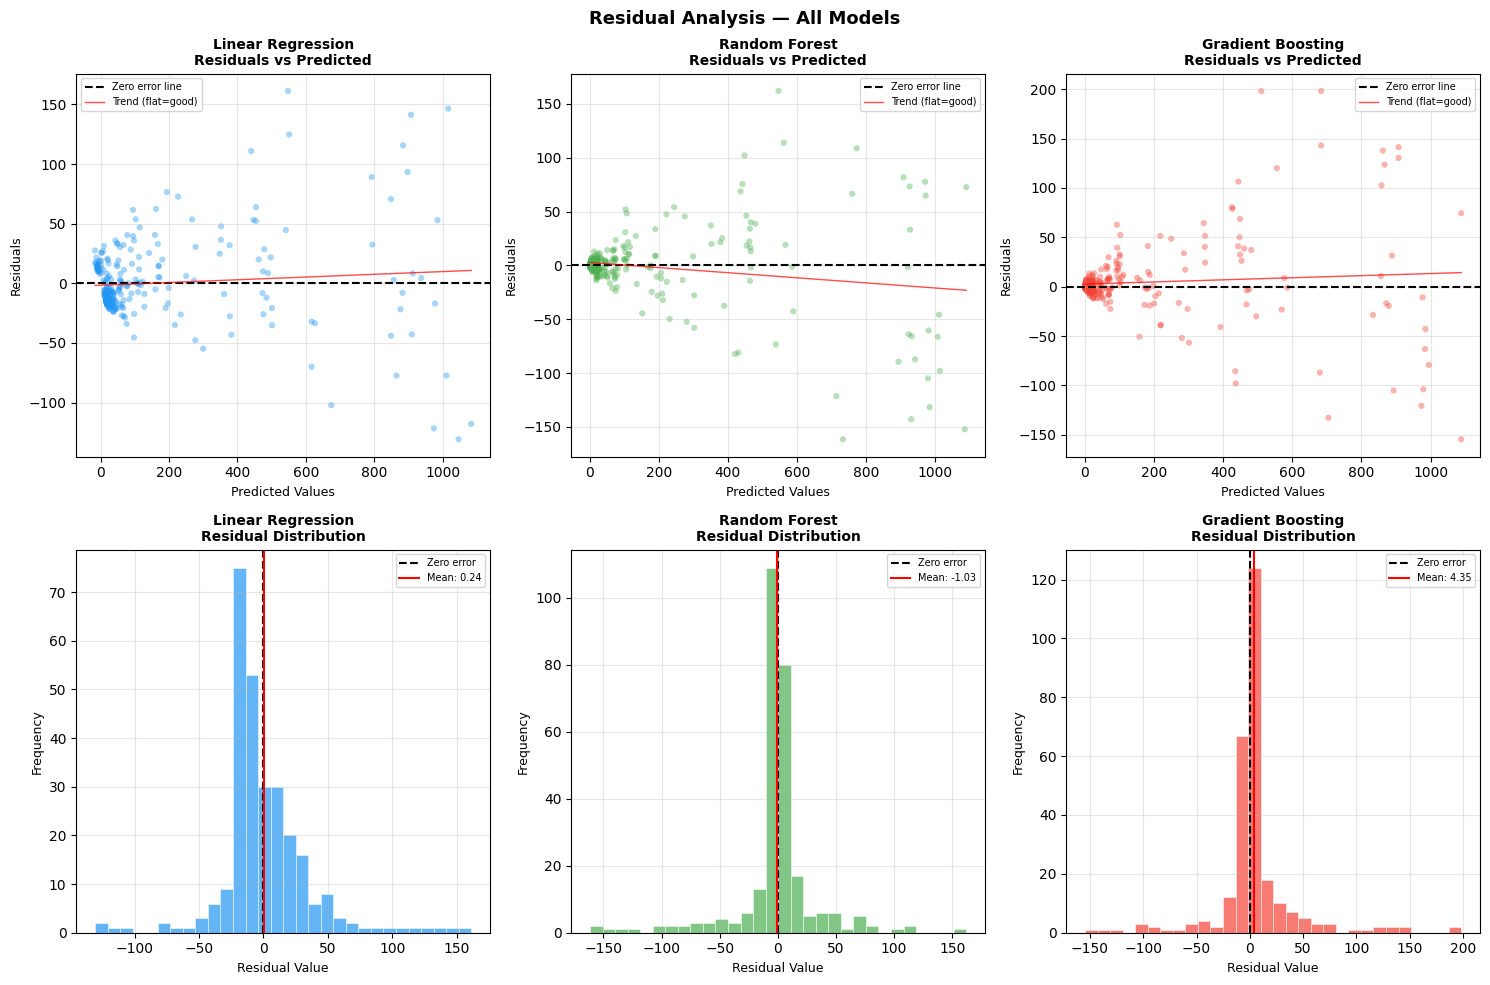

── Residual Statistics ───────────────────────────────────────

Linear Regression:
  Mean residual:   0.2363 (close to 0 = no bias)
  Std residual:    34.6544
  Max over-pred:   -130.74
  Max under-pred:  161.25

Random Forest:
  Mean residual:   -1.0263 (close to 0 = no bias)
  Std residual:    34.6733
  Max over-pred:   -161.44
  Max under-pred:  162.10

Gradient Boosting:
  Mean residual:   4.3526 (close to 0 = no bias)
  Std residual:    38.2103
  Max over-pred:   -154.54
  Max under-pred:  198.23

 Residual analysis saved!


In [ ]:
# ============================================================
# Step 3g: Residual Analysis
# Purpose: Verify model assumptions by examining prediction errors. Random scatter around zero = good model.
#          Systematic patterns = model is missing something. Normal residual distribution = assumptions are met.
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Residual Analysis — All Models',
             fontsize=13, fontweight='bold')

models_info = [
    ('Linear Regression', y_pred_lr, '#2196F3'),
    ('Random Forest',     y_pred_rf, '#4CAF50'),
    ('Gradient Boosting', y_pred_gb, '#F44336')
]

for col_idx, (name, y_pred, color) in enumerate(models_info):

    # Calculate residuals
    residuals = y_test.values - y_pred

    # ── Top row: Residuals vs Predicted ───────────────────────────────
    # Points should be randomly scattered around zero horizontal line
    # Any pattern (funnel shape, curve) = model has systematic errors
    ax_top = axes[0, col_idx]
    ax_top.scatter(y_pred, residuals,
                   alpha=0.4, color=color,
                   s=20, edgecolors='none')

    # Zero reference line
    ax_top.axhline(y=0, color='black',
                   linestyle='--', linewidth=1.5,
                   label='Zero error line')

    # Add trend line to show if systematic bias exists
    z = np.polyfit(y_pred, residuals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(y_pred.min(), y_pred.max(), 100)
    ax_top.plot(x_line, p(x_line),
                color='red', linestyle='-',
                linewidth=1, alpha=0.7,
                label='Trend (flat=good)')

    ax_top.set_xlabel('Predicted Values', fontsize=9)
    ax_top.set_ylabel('Residuals', fontsize=9)
    ax_top.set_title(f'{name}\nResiduals vs Predicted',
                     fontsize=10, fontweight='bold')
    ax_top.legend(fontsize=7)
    ax_top.grid(True, alpha=0.3)

    # ── Bottom row: Residual Histogram ────────────────────────────────
    # Should look like a normal bell curve centred at zero
    # Skewed distribution = systematic over or under prediction
    ax_bot = axes[1, col_idx]
    ax_bot.hist(residuals,
                bins=30,
                color=color,
                alpha=0.7,
                edgecolor='white',
                linewidth=0.5)

    # Add vertical line at zero
    ax_bot.axvline(x=0, color='black',
                   linestyle='--', linewidth=1.5,
                   label='Zero error')

    # Add mean residual line
    mean_resid = residuals.mean()
    ax_bot.axvline(x=mean_resid,
                   color='red', linestyle='-',
                   linewidth=1.5,
                   label=f'Mean: {mean_resid:.2f}')

    ax_bot.set_xlabel('Residual Value', fontsize=9)
    ax_bot.set_ylabel('Frequency', fontsize=9)
    ax_bot.set_title(f'{name}\nResidual Distribution',
                     fontsize=10, fontweight='bold')
    ax_bot.legend(fontsize=7)
    ax_bot.grid(True, alpha=0.3)

plt.tight_layout()

# Save
plt.savefig('/content/drive/MyDrive/DDA/charts/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print residual statistics
print("── Residual Statistics ───────────────────────────────────────")
for name, y_pred, color in models_info:
    residuals = y_test.values - y_pred
    print(f"\n{name}:")
    print(f"  Mean residual:   {residuals.mean():.4f} "
          f"(close to 0 = no bias)")
    print(f"  Std residual:    {residuals.std():.4f}")
    print(f"  Max over-pred:   {residuals.min():.2f}")
    print(f"  Max under-pred:  {residuals.max():.2f}")

print("\n Residual analysis saved!")

In [ ]:
# ============================================================
# Step 4: High Performance Computational Implementation
# Purpose: Implement distributed Random Forest using Apache PySpark to demonstrate scalable ML on the UK
#          insolvency dataset.
# ============================================================

# ── Step 4a: Install PySpark ──────────────────────────────────────────
# -q flag suppresses verbose installation output.

!pip install pyspark -q

# Verify installation
import pyspark
print(f"PySpark version {pyspark.__version__} installed successfully!")

# ── Step 4b: Initialise Spark Session ────────────────────────────────
# SparkSession is the single entry point to all PySpark functionality.
# It manages the connection to the distributed computing engine.
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("UK_Insolvency_Prediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# Confirm Spark is running
print(f"Spark version:  {spark.version}")
print(f"App name:       {spark.sparkContext.appName}")
print(f"Master:         {spark.sparkContext.master}")
print("\nSpark session started successfully!")

# ── Step 4c: Load Dataset into Spark DataFrame ────────────────────────
# Spark DataFrames differ fundamentally from pandas DataFrames:
# - Data is partitioned across available CPU cores/cluster nodes
# - Operations execute lazily — compiled into optimised plans
# - Fault tolerant via Resilient Distributed Datasets (RDDs)
#
# inferSchema=True: Spark automatically detects column data types
# header=True: first row contains column names
spark_df = spark.read.csv(
    '/content/drive/MyDrive/DDA/datasets/merged_complete_dataset.csv',
    header=True,
    inferSchema=True
)

# Remove Q1 2026 — beyond interest rate data coverage
spark_df = spark_df.filter(spark_df.Quarter != 'Q1 2026')

# Validate data loaded correctly
print(f"Total rows loaded: {spark_df.count()}")
print(f"Total columns:     {len(spark_df.columns)}")
print(f"\nSchema (column data types):")
spark_df.printSchema()

# ── Step 4d: Feature Assembly and Train/Test Split ────────────────────
# Spark MLlib requires ALL features combined into a SINGLE vector column.
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor as SparkRF
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import monotonically_increasing_id, col

target = 'Insolvency_Count'

spark_renamed = spark_df.withColumnRenamed('time_index', 't_index')

# ── Define features ───────────────────────────────────────────────────
features_spark = [
    'Average_Interest_Rate',  # Borrowing cost
    'Energy_Price_Index',     # Energy cost
    'Regional_GDP',           # Economic strength
    'lag_1',                  # Previous quarter insolvency count
    'lag_2',                  # Two quarters ago insolvency count
    'rolling_avg_4',          # 4-quarter rolling average
    'Sector_code',            # Sector encoded as integer
    'Location_code',          # Location encoded as integer
    't_index'                 # Sequential time marker
]

# ── Sort chronologically ───────────────────────────────────────────────
# Essential before splitting to preserve temporal order
spark_sorted = spark_renamed.sort('t_index')

# ── Assemble features into single vector column ───────────────────────
# handleInvalid='skip' drops any rows with null feature values
assembler = VectorAssembler(
    inputCols=features_spark,
    outputCol='features',
    handleInvalid='skip'
)

spark_assembled = assembler.transform(spark_sorted)

# Select only features vector and target column
# Drops all other columns to clean up DataFrame
spark_final = spark_assembled.select('features', target)

# ── Time-based 80/20 train/test split ─────────────────────────────────
# monotonically_increasing_id assigns sequential row numbers
# after chronological sorting — enabling index-based time split
spark_indexed = spark_final.withColumn(
    'row_id', monotonically_increasing_id()
)

total_rows = spark_indexed.count()
train_size = int(total_rows * 0.8)

# First 80% = training, last 20% = testing
train_data = (spark_indexed
              .filter(col('row_id') < train_size)
              .drop('row_id'))
test_data  = (spark_indexed
              .filter(col('row_id') >= train_size)
              .drop('row_id'))

print(f"Total rows:    {total_rows}")
print(f"Training rows: {train_data.count()} (80%)")
print(f"Testing rows:  {test_data.count()} (20%)")

PySpark version 4.0.2 installed successfully!
Spark version:  4.0.2
App name:       UK_Insolvency_Prediction
Master:         local[*]

Spark session started successfully!
Total rows loaded: 1468
Total columns:     16

Schema (column data types):
root
 |-- year_int: integer (nullable = true)
 |-- quarter_num: integer (nullable = true)
 |-- Quarter: string (nullable = true)
 |-- Sector: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- Insolvency_Count: integer (nullable = true)
 |-- time_index: double (nullable = true)
 |-- lag_1: double (nullable = true)
 |-- lag_2: double (nullable = true)
 |-- rolling_avg_4: double (nullable = true)
 |-- Sector_code: integer (nullable = true)
 |-- Location_code: integer (nullable = true)
 |-- Risk_level: integer (nullable = true)
 |-- Average_Interest_Rate: double (nullable = true)
 |-- Energy_Price_Index: double (nullable = true)
 |-- Regional_GDP: double (nullable = true)

Total rows:    1468
Training rows: 1174 (80%)
Testing ro

In [ ]:
# ── Step 4e: Train and Evaluate PySpark Random Forest ─────────────────
# Implements distributed Random Forest using Spark MLlib.

# ── Define and train PySpark Random Forest ────────────────────────────
spark_rf = SparkRF(
    featuresCol='features',   # Assembled feature vector column
    labelCol=target,          # Target: Insolvency_Count
    numTrees=200,
    maxDepth=10,
    seed=42
)

# Record training time for performance comparison
start_time  = time.time()
spark_model = spark_rf.fit(train_data)
spark_time  = time.time() - start_time

print(f"PySpark Random Forest trained in {spark_time:.3f} seconds")

# ── Generate predictions on test data ─────────────────────────────────
predictions = spark_model.transform(test_data)

# ── Evaluate with three metrics ───────────────────────────────────────
# RegressionEvaluator computes each metric separately in Spark.
# Three evaluators created — one per metric — for RMSE, MAE and R².
spark_rmse = RegressionEvaluator(
    labelCol=target, predictionCol='prediction',
    metricName='rmse').evaluate(predictions)

spark_mae  = RegressionEvaluator(
    labelCol=target, predictionCol='prediction',
    metricName='mae').evaluate(predictions)

spark_r2   = RegressionEvaluator(
    labelCol=target, predictionCol='prediction',
    metricName='r2').evaluate(predictions)

# ── Print PySpark results ─────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  PySpark Random Forest Results")
print(f"{'='*45}")
print(f"  RMSE:          {spark_rmse:.2f}")
print(f"  MAE:           {spark_mae:.2f}")
print(f"  R²:            {spark_r2:.4f}")
print(f"  Training Time: {spark_time:.3f} seconds")

# ── Extract sklearn metrics safely ───────────────────────────────────
try:
    rf_metrics = metrics_dict["Random Forest (sklearn)"]

    rf_rmse = rf_metrics['RMSE']
    rf_mae  = rf_metrics['MAE']
    rf_r2   = rf_metrics['R2']
    rf_time = rf_metrics['Training_Time']

    # ── Comparison Table ─────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  COMPARISON: sklearn RF vs PySpark RF")
    print(f"{'='*50}")
    print(f"  {'Metric':<15} {'sklearn RF':>12} {'PySpark RF':>12}")
    print(f"  {'-'*39}")
    print(f"  {'RMSE':<15} {rf_rmse:>12.2f} {spark_rmse:>12.2f}")
    print(f"  {'MAE':<15} {rf_mae:>12.2f} {spark_mae:>12.2f}")
    print(f"  {'R²':<15} {rf_r2:>12.4f} {spark_r2:>12.4f}")
    print(f"  {'Training Time':<15} {rf_time:>11.3f}s {spark_time:>11.3f}s")

    print(f"\n  Speed difference: PySpark is "
          f"{spark_time/rf_time:.1f}x slower on this dataset")

except NameError:
    print("\n sklearn metrics not found — run Step 3c first.")

except KeyError:
    print("\n 'Random Forest (sklearn)' not found in metrics_dict.")


# ── Save PySpark results ──────────────────────────────
spark_results = pd.DataFrame([{
    'Model':         'PySpark Random Forest (HPC)',
    'RMSE':          round(spark_rmse, 2),
    'MAE':           round(spark_mae, 2),
    'R2':            round(spark_r2, 4),
    'Training_Time': round(spark_time, 3)
}])

spark_results.to_csv(
    '/content/drive/MyDrive/DDA/results/vedanshi_hpc_results.csv',
    index=False
)
print(f"\n PySpark results saved: vedanshi_hpc_results.csv")

# ── Stop Spark session ────────────────────────────────────────────────
spark.stop()
print("\n Spark session stopped — memory released")

PySpark Random Forest trained in 31.705 seconds

  PySpark Random Forest Results
  RMSE:          35.32
  MAE:           17.31
  R²:            0.9821
  Training Time: 31.705 seconds

  COMPARISON: sklearn RF vs PySpark RF
  Metric            sklearn RF   PySpark RF
  ---------------------------------------
  RMSE                   34.69        35.32
  MAE                    17.71        17.31
  R²                    0.9830       0.9821
  Training Time         0.969s      31.705s

  Speed difference: PySpark is 32.7x slower on this dataset

 PySpark results saved: vedanshi_hpc_results.csv

 Spark session stopped — memory released


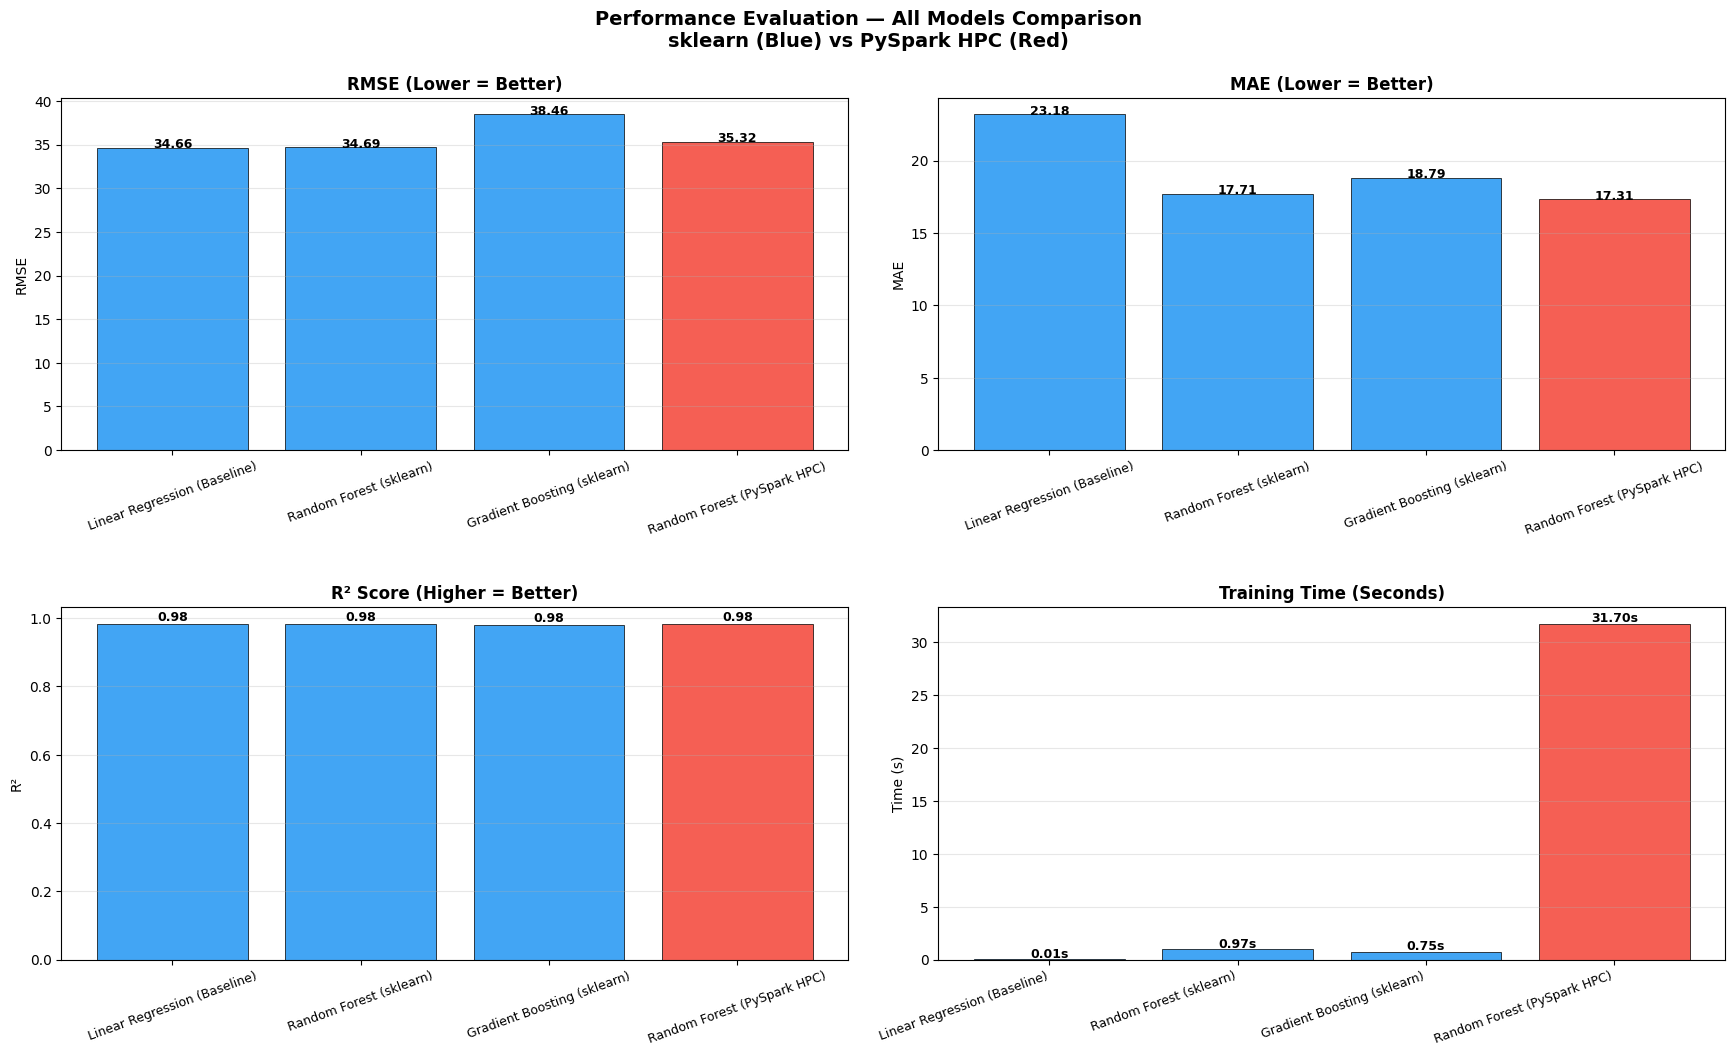

Performance comparison chart saved to Google Drive!

── Final Results Summary ────────────────────────────────────
                       Model      RMSE       MAE       R2  Training_Time
Linear Regression (Baseline) 34.660000 23.180000 0.983000          0.015
     Random Forest (sklearn) 34.690000 17.710000 0.983000          0.969
 Gradient Boosting (sklearn) 38.460000 18.790000 0.979100          0.752
 Random Forest (PySpark HPC) 35.318302 17.308493 0.982057         31.705

── Best Model Per Metric ───────────────────────────────
Best RMSE: Linear Regression (Baseline)
Best MAE : Random Forest (PySpark HPC)
Best R²  : Linear Regression (Baseline)
Fastest  : Linear Regression (Baseline)

 Complete results saved: vedanshi_all_results.csv


In [ ]:
# ============================================================
# Step 5: Performance Evaluation and Comparison
# Purpose: Create comprehensive visual comparison of all four model implementations — Linear Regression,
#          Random Forest, Gradient Boosting (all sklearn) and PySpark Random Forest (HPC).
# ============================================================

all_results = pd.DataFrame([
    {
        'Model':         'Linear Regression (Baseline)',
        'RMSE':          lr_rmse,
        'MAE':           lr_mae,
        'R2':            lr_r2,
        'Training_Time': round(lr_time, 3)
    },
    {
        'Model':         'Random Forest (sklearn)',
        'RMSE':          rf_rmse,
        'MAE':           rf_mae,
        'R2':            rf_r2,
        'Training_Time': round(rf_time, 3)
    },
    {
        'Model':         'Gradient Boosting (sklearn)',
        'RMSE':          gb_rmse,
        'MAE':           gb_mae,
        'R2':            gb_r2,
        'Training_Time': round(gb_time, 3)
    },
    {
        'Model':         'Random Forest (PySpark HPC)',
        'RMSE':          spark_rmse,
        'MAE':           spark_mae,
        'R2':            spark_r2,
        'Training_Time': round(spark_time, 3)
    }
])

# ── Define bar colours ────────────────────────────────────────────────
# Blue = sklearn models, Red = PySpark HPC model
colors = ['#2196F3', '#2196F3', '#2196F3', '#F44336']

# ── Create 4-panel comparison figure ─────────────────────────────────
# Panel 1: RMSE     — lower is better
# Panel 2: MAE      — lower is better
# Panel 3: R²       — higher is better
# Panel 4: Training time — shows distributed computing overhead
# Y-axes zoomed in on panels 1-3 to make small differences visible
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle(
    'Performance Evaluation — All Models Comparison\n'
    'sklearn (Blue) vs PySpark HPC (Red)',
    fontsize=14, fontweight='bold'
)

def plot_bar(ax, metric, title, ylabel, is_time=False):
    bars = ax.bar(
        all_results['Model'],
        all_results[metric],
        color=colors,
        edgecolor='black',
        linewidth=0.6,
        alpha=0.85
    )

    # value labels
    for bar, val in zip(bars, all_results[metric]):
        offset = 0.2 if is_time else 0.01
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.2f}' if not is_time else f'{val:.2f}s',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)

# ── Panel 1: RMSE ────────────────────────────────────────────────────
# Root Mean Squared Error — average prediction error in insolvency units
# Penalises large errors more heavily than MAE
plot_bar(
    axes[0, 0],
    'RMSE',
    'RMSE (Lower = Better)',
    'RMSE'
)

# ── Panel 2: MAE ─────────────────────────────────────────────────────
# Mean Absolute Error — average prediction error treating all equally
# More intuitive than RMSE — directly interpretable in insolvency units
plot_bar(
    axes[0, 1],
    'MAE',
    'MAE (Lower = Better)',
    'MAE'
)

# ── Panel 3: R² ──────────────────────────────────────────────────────
# R-squared — proportion of variance in insolvency explained by model
# Range 0 to 1 — higher is better
plot_bar(
    axes[1, 0],
    'R2',
    'R² Score (Higher = Better)',
    'R²'
)

# ── Panel 4: Training Time ────────────────────────────────────────────
plot_bar(
    axes[1, 1],
    'Training_Time',
    'Training Time (Seconds)',
    'Time (s)',
    is_time=True
)

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.90)
plt.xticks(rotation=20, ha='right')

# ── Save ──────────────────────────────────────────────
plt.savefig(
    '/content/drive/MyDrive/DDA/charts/performance_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Performance comparison chart saved to Google Drive!")

# ── Print final summary table ─────────────────────────────────────────
print("\n── Final Results Summary ────────────────────────────────────")
print(all_results.to_string(index=False))

## ── Best Model Identification ────────────────────────────────
print("\n── Best Model Per Metric ───────────────────────────────")

print("Best RMSE:",
      all_results.loc[all_results['RMSE'].idxmin(), 'Model'])

print("Best MAE :",
      all_results.loc[all_results['MAE'].idxmin(), 'Model'])

print("Best R²  :",
      all_results.loc[all_results['R2'].idxmax(), 'Model'])

print("Fastest  :",
      all_results.loc[all_results['Training_Time'].idxmin(), 'Model'])


# ── Save ─────────────────────────────
all_results.to_csv(
    '/content/drive/MyDrive/DDA/results/vedanshi_all_results.csv',
    index=False
)
print("\n Complete results saved: vedanshi_all_results.csv")